In [94]:
%load_ext autoreload
%autoreload 2

import sys
import featuregraph as fg
from featuregraph.behaviors.transition import Transition

from featuregraph.operators.states import (
    rising_state
)

print("Python:", sys.executable)
print("FeatureGraph:", fg.__file__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Python: /usr/local/bin/python
FeatureGraph: /workspaces/featuregraph/src/featuregraph/__init__.py


In [95]:
# create a transition object

In [111]:
diff_lag = 10
eps = 0.01

bidmc = fg.datasets.bidmc(subject=1)

bidmc['respiration_smooth'] = bidmc['respiration'].rolling(50).mean()

bidmc_transition = Transition(
    bidmc,
    signal="respiration_smooth",
    direction='rising',
    op=rising_state,
    group="subject",
    diff_lag=diff_lag,
    eps=eps,
)

df = bidmc_transition.df
df['respiration_smooth'] = df['respiration'].rolling(100).max().rolling(100).mean().shift(-100)
df['respiration_rising'] = df['respiration_smooth'].diff() > 0
df['respiration_falling'] = df['respiration_smooth'].diff() < 0
df['exit_respiration_rising'] = df['respiration_rising'].astype(int).diff() == -1
# df['respiration_sustained_rise'] = df['respiration_rising'].astype(int).diff() == 1
# df['rate_of_change'] = df['respiration'].diff()
# df['max_rate_of_change'] = df.groupby('respiration_id').transform('max')['rate_of_change']
# df['mean_rate_of_change'] = df.groupby('respiration_id').transform('mean')['rate_of_change']

(<Figure size 1600x880 with 4 Axes>,
 array([<Axes: ylabel='respiration'>, <Axes: ylabel='respiration_smooth'>,
        <Axes: ylabel='respiration_rising'>,
        <Axes: xlabel='Time', ylabel='exit_respiration_rising'>],
       dtype=object))

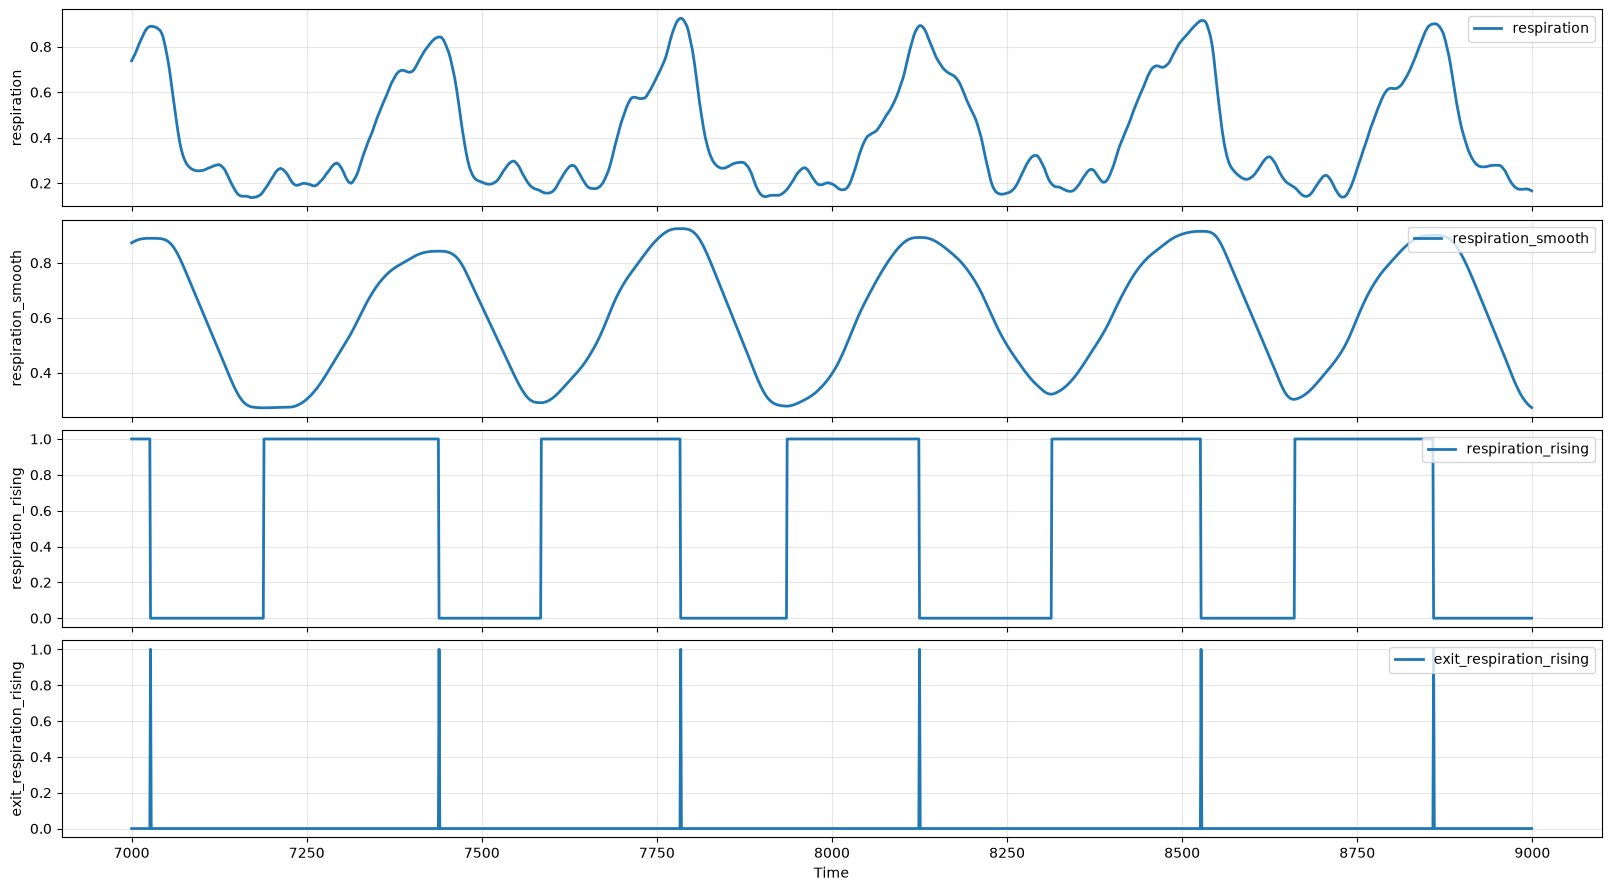

In [113]:
fg.plot(df[7000:9000], [['respiration'],
                              ['respiration_smooth'],
                            #   ['respiration_sustained_rise'],
                              ['respiration_rising'],
                              ['exit_respiration_rising'],
                            #   ['respiration_id'],
                            #   ['max_rate_of_change'],
                            #   ['mean_rate_of_change']
                             ]
)

In [98]:
summarydf = bidmc_transition.summary()

In [99]:
summarydf[50:80]

,duration,start_value,end_value,net_change,mean_rate
respiration_smooth_id,,,,,
50,29,0.85728,0.27859,-0.57869,-0.019955
51,126,0.27859,1.00000,0.72141,0.005725
52,27,1.00000,0.41642,-0.58358,-0.021614
53,133,0.41056,0.98827,0.57771,0.004344
54,29,0.98827,0.53177,-0.45650,-0.015741
55,188,0.51906,0.33529,-0.18377,-0.000977
56,147,0.33529,0.36755,0.03226,0.000219
57,132,0.36364,0.34604,-0.01760,-0.000133
58,139,0.34604,1.00000,0.65396,0.004705
